# Analysis of centrality (in progress)  

#### Done
1. Betweenness centrality data stored in raw/betw.pkl arranged in descending order
2. Removing nodes (taking every 20th node set to remove)
3. Plotting waveforms for parameters in case 2
4. Plot distribution of betweenness centrality for node pairs over transition count

#### To do
1. On removing node sets, sometimes there is not a single  transition. Find out why?
2.  Can check pairs to which community it belongs ?
3. Extracting other network measures like connector hub or rich club nodes
4. For a node to be connector hub, it should have high degree, high betweenness centrality and high nodal efficiency
   


#### Import packages

In [1]:
%reload_ext autoreload
%autoreload 2

import networkx as nx
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.DataUtils import DataUtils

import glob

import numpy as np

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

#### Create objects

In [2]:
net_meas = DataUtils()
reader = DataRead()
analyse = AnalysisFunc()

../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


#### Reading betweenness centrality data

In [8]:
# loading nodes in descending order of their betweenness centrality
b=reader.data_read_pkl('raw/betw.pkl')


# plot 

#### Getting node pairs after every 20th gap

In [9]:
#counting every 20th node set
nodes=list(b.keys())
betw_nodes=[nodes[0],nodes[1]]
plot_nodes =[]
i=1
while i < 426:
    if i%20==0:
        betw_nodes.append(nodes[i-2])
        betw_nodes.append(nodes[i-1])
    i+=1
print(betw_nodes)
print(len(betw_nodes))
betw_nodes
j=0
while j < len(betw_nodes):
    plot_nodes.append(betw_nodes[j])
    
    j+=2

print(plot_nodes)
    
print(len(plot_nodes))


[214, 1, 326, 113, 271, 58, 301, 88, 366, 153, 242, 29, 160, 373, 33, 246, 369, 156, 122, 335, 51, 264, 114, 327, 132, 345, 213, 0, 309, 96, 334, 121, 283, 70, 50, 263, 158, 371, 32, 245, 73, 286, 303, 90]
44
[214, 326, 271, 301, 366, 242, 160, 33, 369, 122, 51, 114, 132, 213, 309, 334, 283, 50, 158, 32, 73, 303]
22


#### To keep records from above node sets as global order data and local order data gets extracted
Done  
n1 214,1  
n2 326,113  
n3 271,58  
n4 301,88  
n5 366,153  
n6 242,29  
n7 160,373  
n8 33,246  
n9 369, 156  
n10 122, 335  
n11 51,264  
n12 114,327  
n13 132, 345  
n14 213, 0  
n15 309,96  
n16 334,121  
n17 283,70  
n18 50,263  
n19 158,371  
n20 32, 245  
n21 73,286  
n22 303,90  









 

 


In [10]:
val=[]
for i in plot_nodes:
    val.append(b[i])
    





In [ ]:
reader.ext_global_order(200, "raw/check_bet/itr_200_n22.bz2", "raw/check_bet/loc_200_n22.bz2")

#### Load data to plot

../../data/raw/check_bet
['../../data/raw/check_bet/itr_200_4.bz2', '../../data/raw/check_bet/itr_200_n13.bz2', '../../data/raw/check_bet/itr_200_n10.bz2', '../../data/raw/check_bet/itr_200_1.bz2', '../../data/raw/check_bet/itr_200_9.bz2', '../../data/raw/check_bet/itr_200_n19.bz2', '../../data/raw/check_bet/itr_200_n17.bz2', '../../data/raw/check_bet/itr_200_n16.bz2', '../../data/raw/check_bet/itr_200_n15.bz2', '../../data/raw/check_bet/itr_200_5.bz2', '../../data/raw/check_bet/itr_200_n22.bz2', '../../data/raw/check_bet/itr_200_6.bz2', '../../data/raw/check_bet/itr_200_3.bz2', '../../data/raw/check_bet/itr_200_7.bz2', '../../data/raw/check_bet/itr_200_n11.bz2', '../../data/raw/check_bet/itr_200_2.bz2', '../../data/raw/check_bet/itr_200_n14.bz2', '../../data/raw/check_bet/itr_200_n18.bz2', '../../data/raw/check_bet/itr_200_n12.bz2', '../../data/raw/check_bet/itr_200_n21.bz2', '../../data/raw/check_bet/itr_200_n20.bz2', '../../data/raw/check_bet/itr_200_8.bz2']
Number of transitions / 

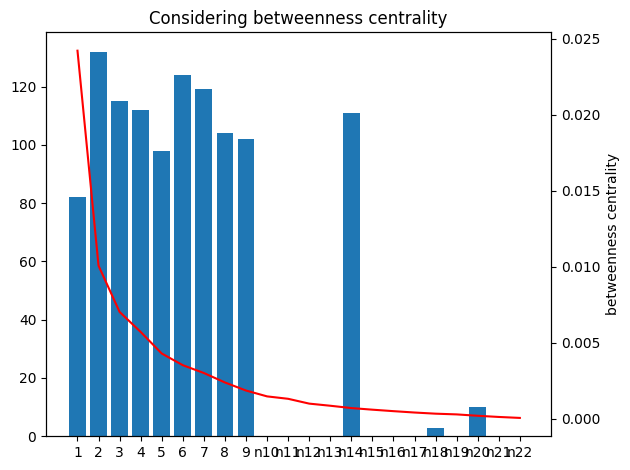

In [19]:
data_folder = Path(f'../../data/raw/check_bet')
print(data_folder)
# Use glob to match files with a pattern
#f=pd.read_csv('../../data/')

files = glob.glob(str(data_folder / "itr_200*.bz2"))
print(files)
x=[]
itr_count=[]
for f in files:

    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[2]
    x.append(name_suffix)
    df_d = pd.read_pickle(f, compression="bz2")

    l=analyse.compute_param(df_d,0.05)
    num=l['tran_per'][-1]
    itr_count.append(num)

#plotting above as bar plot 
# sorting in ascending order

# uncomment below when need to plt in ascending order

# itr_count_arr=np.array(itr_count)
# ind=itr_count_arr.argsort()
# itr_count.sort()
# x=np.array(x)
# x=x[ind]

# SORT IN BETWEENNESS CENTRALITY DESCENDING ORDER

x_arr=np.array(x)
ind=x_arr.argsort()
x.sort()
itr_count=np.array(itr_count)
itr_count=itr_count[ind]

plt.bar(x,itr_count)
plt.twinx()


plt.plot(val,'r')
plt.title('Considering betweenness centrality')
plt.ylabel('betweenness centrality')
plt.xlabel('node set removed')
plt.tight_layout()
# print(f)

print(x)


In [16]:
i=np.array(x).argsort()
print(i)


x



[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]


['1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 'n10',
 'n11',
 'n12',
 'n13',
 'n14',
 'n15',
 'n16',
 'n17',
 'n18',
 'n19',
 'n20',
 'n21',
 'n22']

#### Very weird result !! Checking some node sets to make sure how is original data

Validated

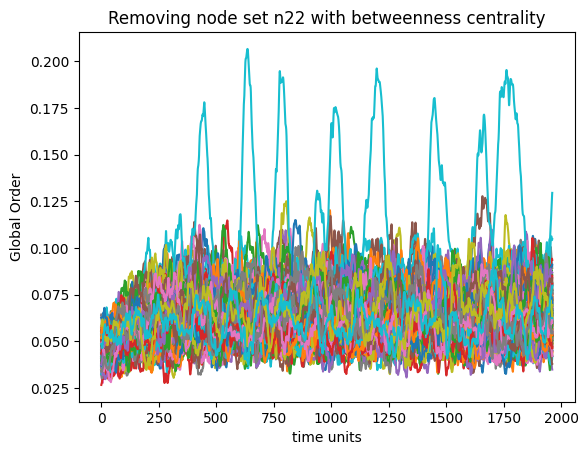

In [22]:
df=reader.data_read_bz2('raw/check_bet/itr_200_n22.bz2')
x=analyse.get_time(df,0.05)
plt.plot(x,analyse.smooth(df))
plt.xlabel('time units')
plt.ylabel('Global Order')
plt.title('Removing node set n22 with betweenness centrality')
plt.show()

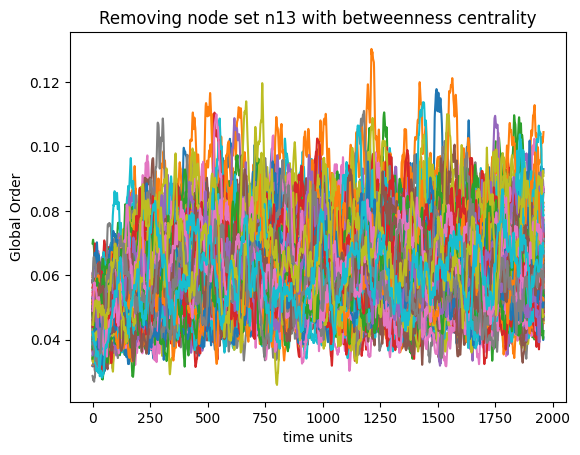

In [23]:
df=reader.data_read_bz2('raw/check_bet/itr_200_n13.bz2')
x=analyse.get_time(df,0.05)
plt.plot(x,analyse.smooth(df))
plt.xlabel('time units')
plt.ylabel('Global Order')
plt.title('Removing node set n13 with betweenness centrality')
plt.show()

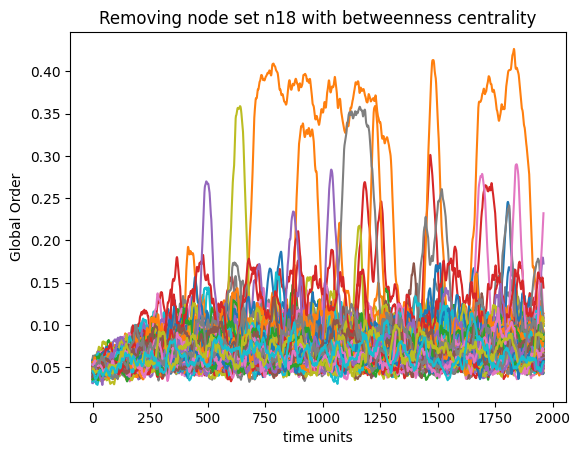

In [24]:
df=reader.data_read_bz2('raw/check_bet/itr_200_n18.bz2')
x=analyse.get_time(df,0.05)
plt.plot(x,analyse.smooth(df))
plt.xlabel('time units')
plt.ylabel('Global Order')
plt.title('Removing node set n18 with betweenness centrality')
plt.show()

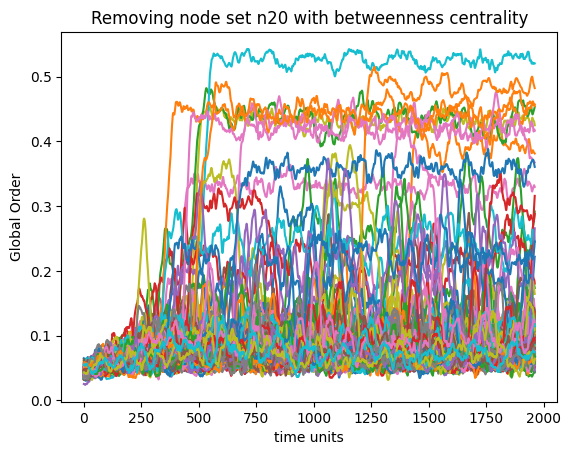

In [26]:
df=reader.data_read_bz2('raw/check_bet/itr_200_n20.bz2')
x=analyse.get_time(df,0.05)
plt.plot(x,analyse.smooth(df))
plt.xlabel('time units')
plt.ylabel('Global Order')
plt.title('Removing node set n20 with betweenness centrality')
plt.show()

# Finding connector hubs

The nodes with high degree centrality as well as high betweenness centrality

In [39]:
G = nx.from_numpy_array(net_meas.WHOLE_BRAIN_CONN)

bet_cent = nx.betweenness_centrality(G)
top_betweenness_centrality= dict(sorted(bet_cent.items(), key=lambda x: x[1], reverse=True))


degree_centrality = nx.degree_centrality(G)
top_degree_centrality = dict(sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True))

deg_cent_sorted =list(top_degree_centrality.keys())[0:20]
print(deg_cent_sorted)

bet_cent_sorted = list(top_betweenness_centrality.keys())[0:20]
print(bet_cent_sorted)

common_node = list(set(deg_cent_sorted) & set(bet_cent_sorted))

common_node

[1, 214, 2, 215, 137, 350, 36, 249, 53, 266, 140, 353, 150, 363, 149, 362, 151, 364, 24, 237]
[214, 1, 137, 350, 2, 215, 36, 249, 266, 53, 95, 308, 171, 384, 164, 377, 167, 380, 326, 113]


[1, 2, 36, 137, 266, 53, 214, 215, 249, 350]

#### Getting order data for connector hubs. 
node pairs:  
1. 214,1.
2. 215,2.
3. 249,36.
4. 137,350
5. 53, 266.

